# Model Inference - Deteksi Penyakit Daun Jagung

- Nama : Rezha Aulia
- Model : EfficientNetB0 - Transfer Learning
- Dataset : Corn or Maize Leaf Disease Dataset

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
import json
import os

## Load Model

In [2]:
model = load_model('model_P2G7_Rezha_Aulia.h5')

with open('class_names.json', 'r') as f:
    class_names = json.load(f)

print('Model berhasil di load')
print(f'Class names : {class_names}')

Model berhasil di load
Class names : ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


## Model Inference

In [3]:
# Fungsi Prediksi
def predict_image(img_path):
    # Load dan preprocessing gambar
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    img_array = img_to_array(img)
    img_preprocessed = preprocess_input(img_array)
    img_expanded = np.expand_dims(img_preprocessed, axis=0)

    # Prediksi
    pred_prob = model.predict(img_expanded, verbose=0)
    pred_idx = np.argmax(pred_prob)
    pred_label = class_names[pred_idx]
    confidence = np.max(pred_prob) * 100

    return img, pred_label, confidence, pred_prob[0]

# Tampilkan Prediksi
def show_prediction(img_path):
    img, pred_label, confidence, all_probs = predict_image(img_path)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Tampilkan gambar
    axes[0].imshow(img)
    axes[0].set_title(f'Prediksi : {pred_label}\nConfidence : {confidence:.1f}%',
                      fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Tampilkan probability kelas
    colors = ['red', 'yellow', 'green', 'blue']
    bars = axes[1].barh(class_names, all_probs * 100, color=colors)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Probability per Kelas')
    axes[1].set_xlim(0, 100)

    for bar, prob in zip(bars, all_probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob*100:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    print(f'Hasil Prediksi : {pred_label}')
    print(f'Confidence     : {confidence:.1f}%') 

## Test Inference


Gambar: inference_1.jpg


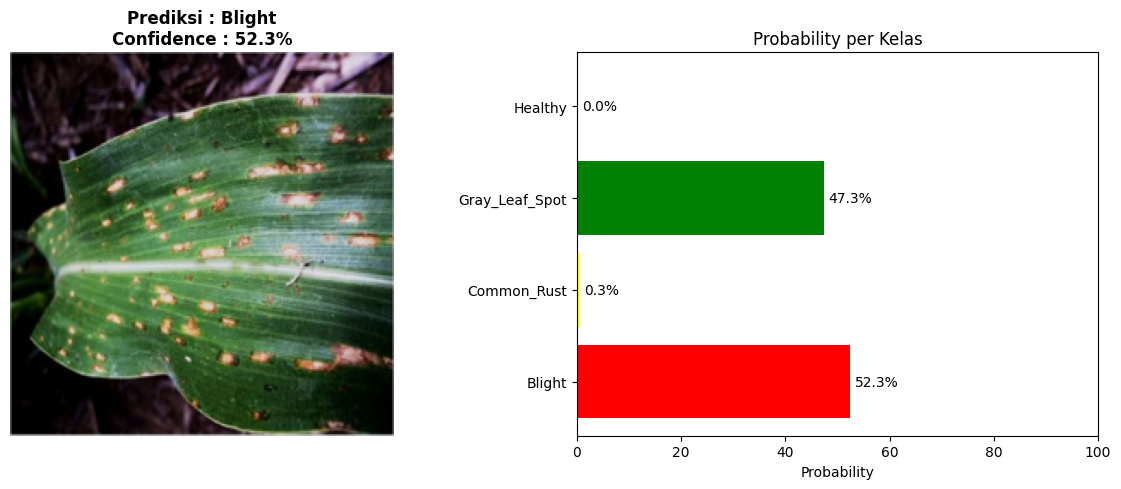

Hasil Prediksi : Blight
Confidence     : 52.3%

Gambar: inference_2.jpg


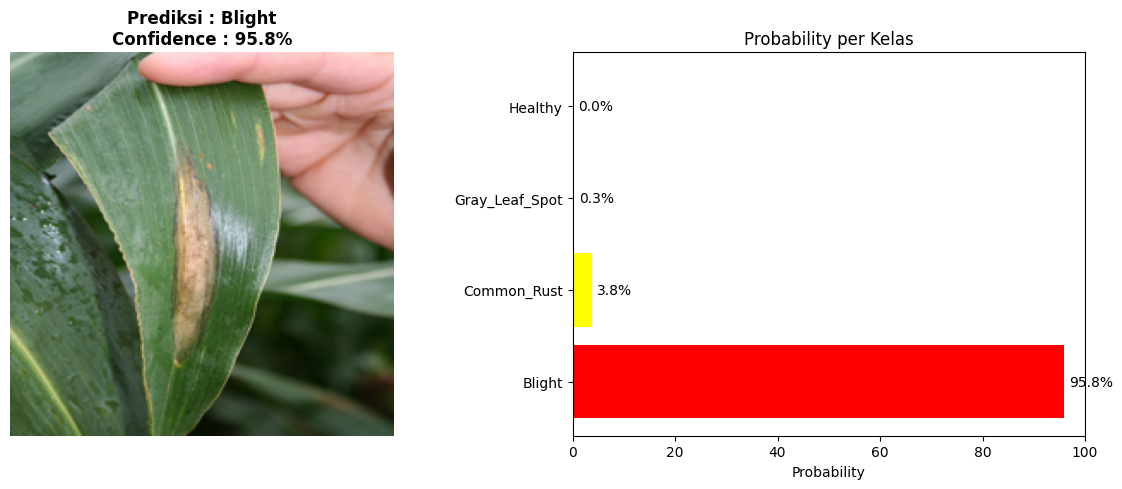

Hasil Prediksi : Blight
Confidence     : 95.8%

Gambar: inference_3.png


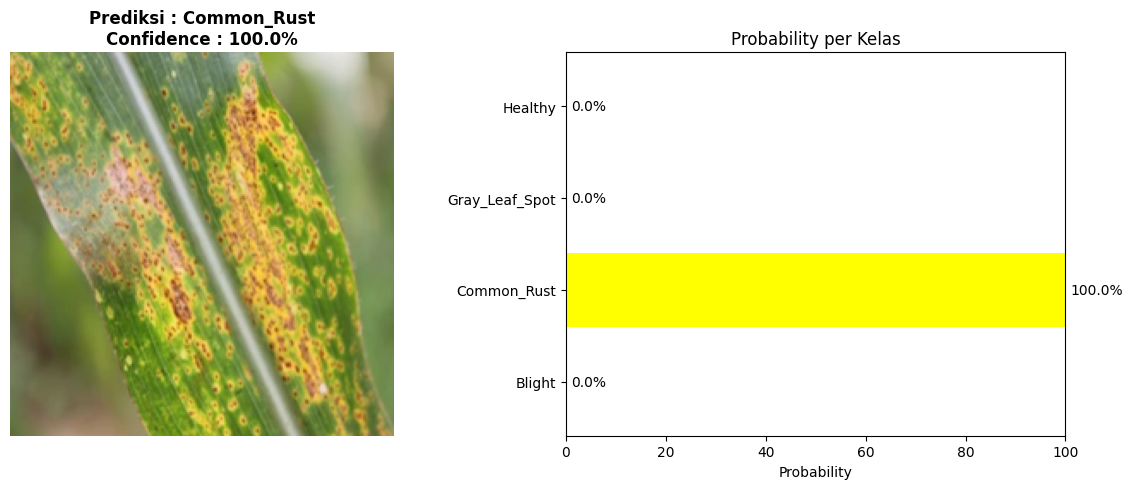

Hasil Prediksi : Common_Rust
Confidence     : 100.0%

Gambar: inference_4.png


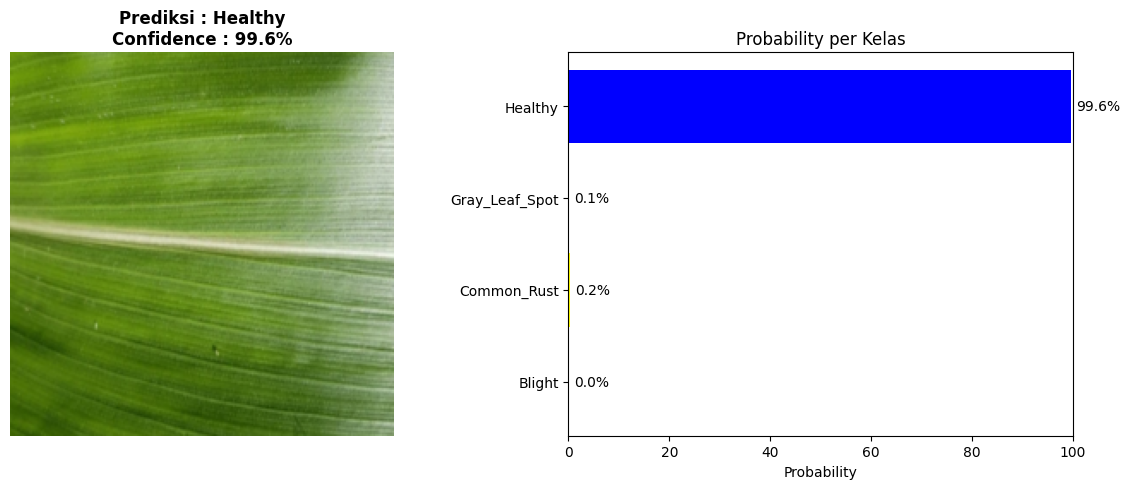

Hasil Prediksi : Healthy
Confidence     : 99.6%


In [4]:
# Gambar baru yang ingin diprediksi
inference_images = [
    'inference_1.jpg',
    'inference_2.jpg',
    'inference_3.png',
    'inference_4.png'
]

for img_path in inference_images:
    if os.path.exists(img_path):
        print(f'\nGambar: {img_path}')
        show_prediction(img_path)
    else:
        print(f'File tidak ditemukan: {img_path}')